Prototipo Projeto CAR

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
from load_data import GeoDataLoader

#carrega dados
arquivos = {
        "car": "dados/PARA/CAR/AREA_IMOVEL_1.shp",
        "municipios": "dados/PARA/Municipios/PA_Municipios_2023.shp",
        "uf": "dados/PARA/UF/PA_UF_2023.shp",
                "UCs": "dados/PARA/UCs/cat60_protected_area_WGS84_v2.shp",

        "Assen.": "dados/PARA/Assentamentos/cat63_settlements_WGS84.shp",
       "Quil.": "dados/PARA/Quilombolas/cat62_quilombola_WGS84.shp",
       
       
        "Agua": "dados/PARA/Agua/geoft_bho_massa_dagua_v2019.shp",
    
       "TIs": "dados/PARA/TIs/cat61_indigenous_territories_WGS84.shp",
}

datasets = GeoDataLoader().load_all(arquivos)

gdf,g_m,uf=datasets["car"],datasets["municipios"],datasets["uf"]






Loading car from dados/PARA/CAR/AREA_IMOVEL_1.shp...
Loading municipios from dados/PARA/Municipios/PA_Municipios_2023.shp...
Loading uf from dados/PARA/UF/PA_UF_2023.shp...
Loading UCs from dados/PARA/UCs/cat60_protected_area_WGS84_v2.shp...
Loading Assen. from dados/PARA/Assentamentos/cat63_settlements_WGS84.shp...
Loading Quil. from dados/PARA/Quilombolas/cat62_quilombola_WGS84.shp...
Loading Agua from dados/PARA/Agua/geoft_bho_massa_dagua_v2019.shp...
Loading TIs from dados/PARA/TIs/cat61_indigenous_territories_WGS84.shp...


In [7]:
print(gdf.head())


      cod_tema        nom_tema                                   cod_imovel  \
0  AREA_IMOVEL  Area do Imovel  PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7   
1  AREA_IMOVEL  Area do Imovel  PA-1500958-D1D6D17578FD40CEA06B42C266271E43   
2  AREA_IMOVEL  Area do Imovel  PA-1506807-5192E004BC54471C814813F0A396613C   
3  AREA_IMOVEL  Area do Imovel  PA-1507607-EA2B29DB07714B218775479DCEFBC906   
4  AREA_IMOVEL  Area do Imovel  PA-1506708-459EEBF6FB804F738EA5FF9F4786FAED   

   mod_fiscal     num_area ind_status ind_tipo                des_condic  \
0  12992.3066  909461.4607         PE      IRU        Aguardando analise   
1      0.3736    4068.0561         AT      AST        Aguardando analise   
2      4.0000  677232.0650         PE      PCT        Aguardando analise   
3      0.2544      13.9904         AT      IRU  Analisado sem pendencias   
4      3.3130     248.4772         PE      IRU        Aguardando analise   

             municipio cod_estado  dat_criaca  dat_atuali  \
0      

In [11]:
import os
import geopandas as gpd
import pandas as pd

# Define the base directory containing the intersection folders
base_dir = "Resultados"

# Initialize an empty list to store GeoDataFrames
intersecting_gdfs = []
names=[]
# Iterate through each folder in the base directory
for folder_name in os.listdir(base_dir):
    #print(folder_name)
    folder_path = os.path.join(base_dir, folder_name)
    if os.path.isdir(folder_path) and folder_name.endswith("_intersect"):
        # Load the intersection data from the folder
        shapefile_path = os.path.join(folder_path, "shapes_intersect.shp")
        if os.path.exists(shapefile_path):
            intersecting_gdf = gpd.read_file(shapefile_path)
  
            # Match CAR IDs from the intersecting set with the loaded CAR set to get CAR status
            intersecting_gdf = intersecting_gdf.merge(
                gdf[['cod_imovel', 'des_condic']], 
                left_on="property_i", 
                right_on="cod_imovel", 
                how="left"
)
            intersecting_gdf["des_condic"]= intersecting_gdf['des_condic'].apply(
            lambda x: "Analisado" if x.startswith("Analisado") else (
                "Cancelado" if x.startswith("Cancelado") else "Em analise"
            )
)
            names.append(folder_name)
            intersecting_gdfs.append(intersecting_gdf)

# Combine all loaded GeoDataFrames into a single GeoDataFrame
if intersecting_gdfs:
    intersecting_gdf = gpd.GeoDataFrame(pd.concat(intersecting_gdfs, ignore_index=True))

# Display the first few rows of the combined GeoDataFrame to verify



# Display the first few rows to verify the merge
print(intersecting_gdf.head())
print(names)

sets=[datasets["UCs"],datasets["TIs"],datasets["Quil."],datasets["Agua"]]

                                    property_i         uc_id  intersecti  \
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  0000.00.0067    0.000187   
1  PA-1500503-46AB8910852449A98F06624E1E71B5FA  0000.00.0067    0.000224   
2  PA-1500503-4E9733D77054479B9CF019748117C251  0000.00.0067    0.000194   
3  PA-1500503-AB02627E34E04BF8BAC2F93B87BA744A  0000.00.0067    0.012330   
4  PA-1500503-1F7A7E9415D848449F33C83929B742E1  0000.00.0067    0.002349   

   overlap_ar                                           geometry  \
0    0.000187  POLYGON ((-52.90082 -0.52911, -52.90338 -0.517...   
1    0.000224  POLYGON ((-53.15803 -0.76515, -53.15868 -0.766...   
2    0.000194  POLYGON ((-53.1595 -0.76853, -53.16043 -0.7702...   
3    0.012330  POLYGON ((-53.13818 -0.70302, -53.13752 -0.703...   
4    0.002349  POLYGON ((-53.28416 -0.72251, -53.28409 -0.722...   

                                    cod_imovel  des_condic  
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  Em analise  
1  PA-150050

/tmp/ipykernel_1622441/2263440231.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_area = sets[row_idx].geometry.area.sum()
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


UCs_intersect


/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


UCs_intersect
UCs_intersect


/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


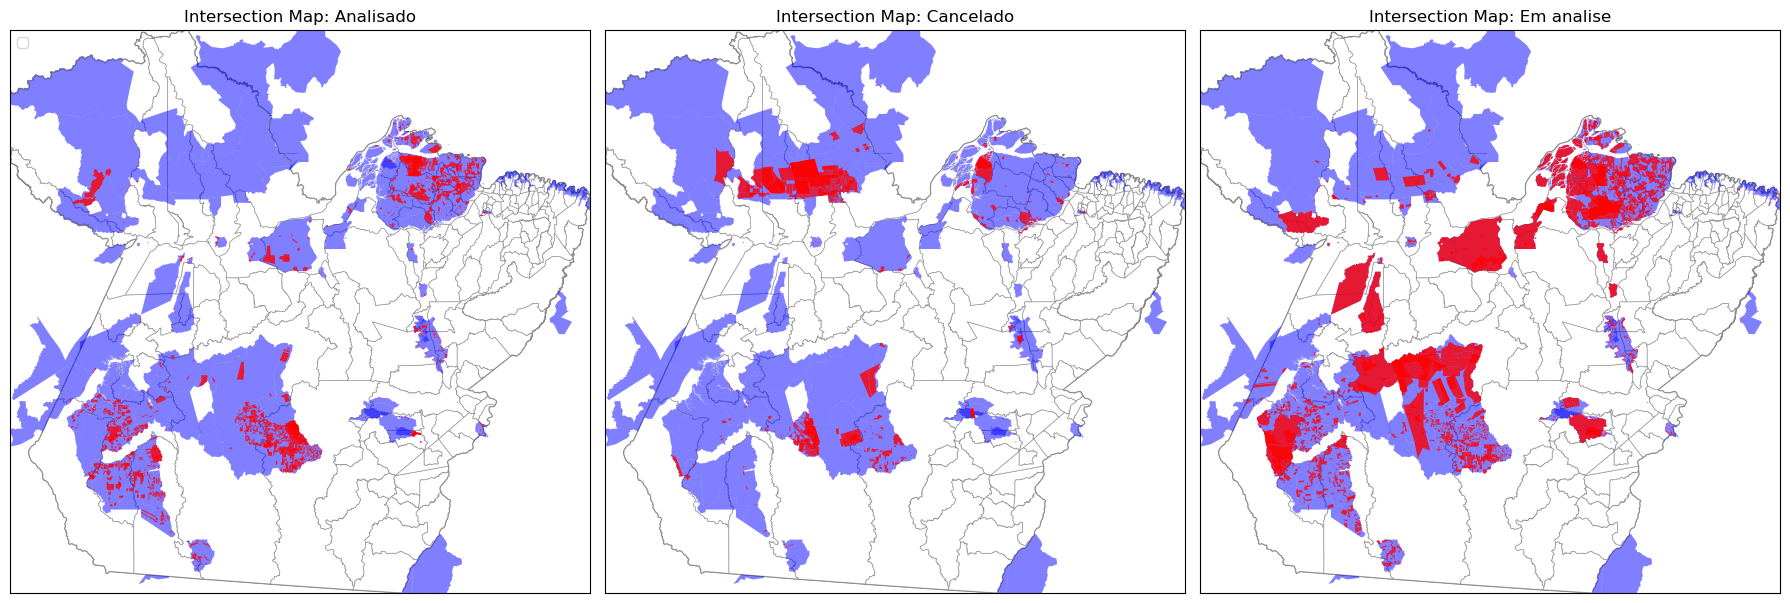

/tmp/ipykernel_1622441/2263440231.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_area = sets[row_idx].geometry.area.sum()
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


TIs_intersect


/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


TIs_intersect
TIs_intersect


/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


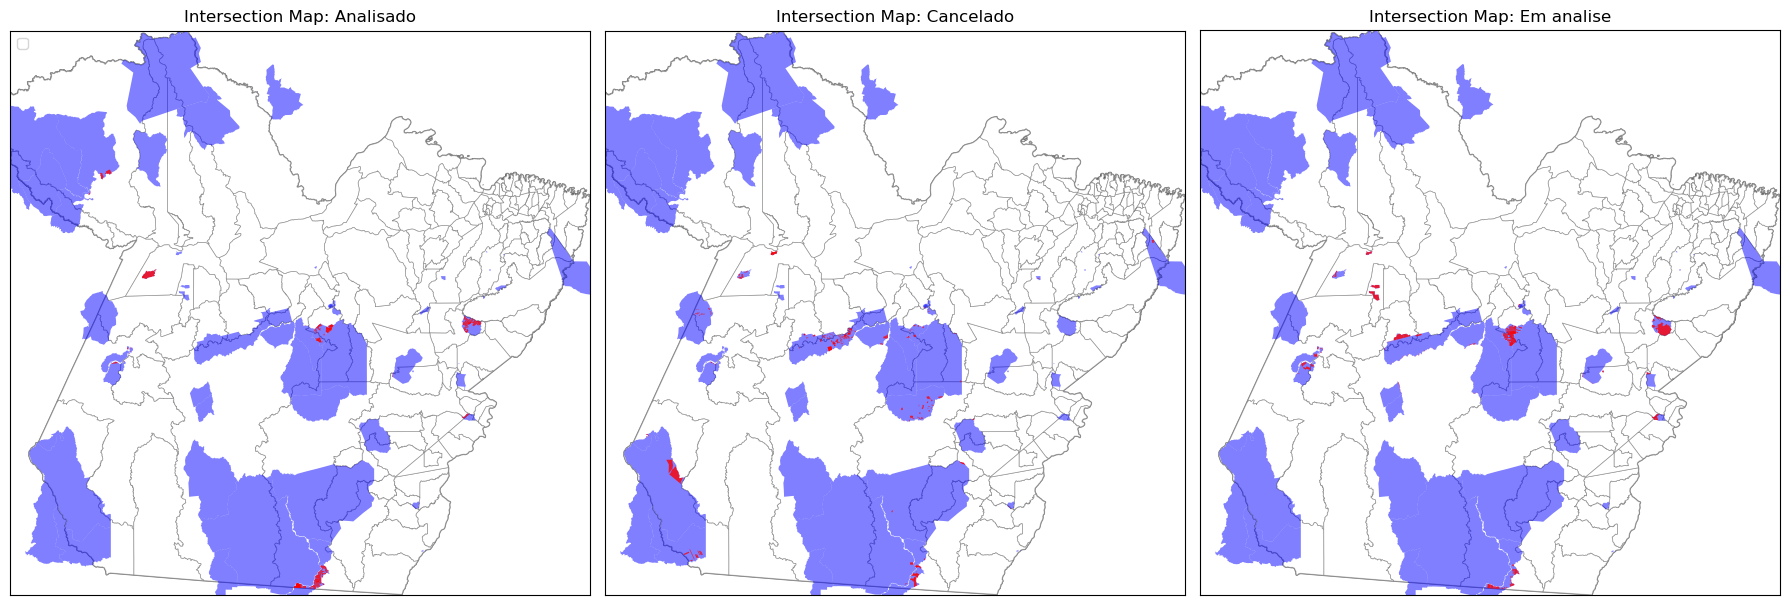

/tmp/ipykernel_1622441/2263440231.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_area = sets[row_idx].geometry.area.sum()
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


Quil._intersect


/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


Quil._intersect
Quil._intersect


/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


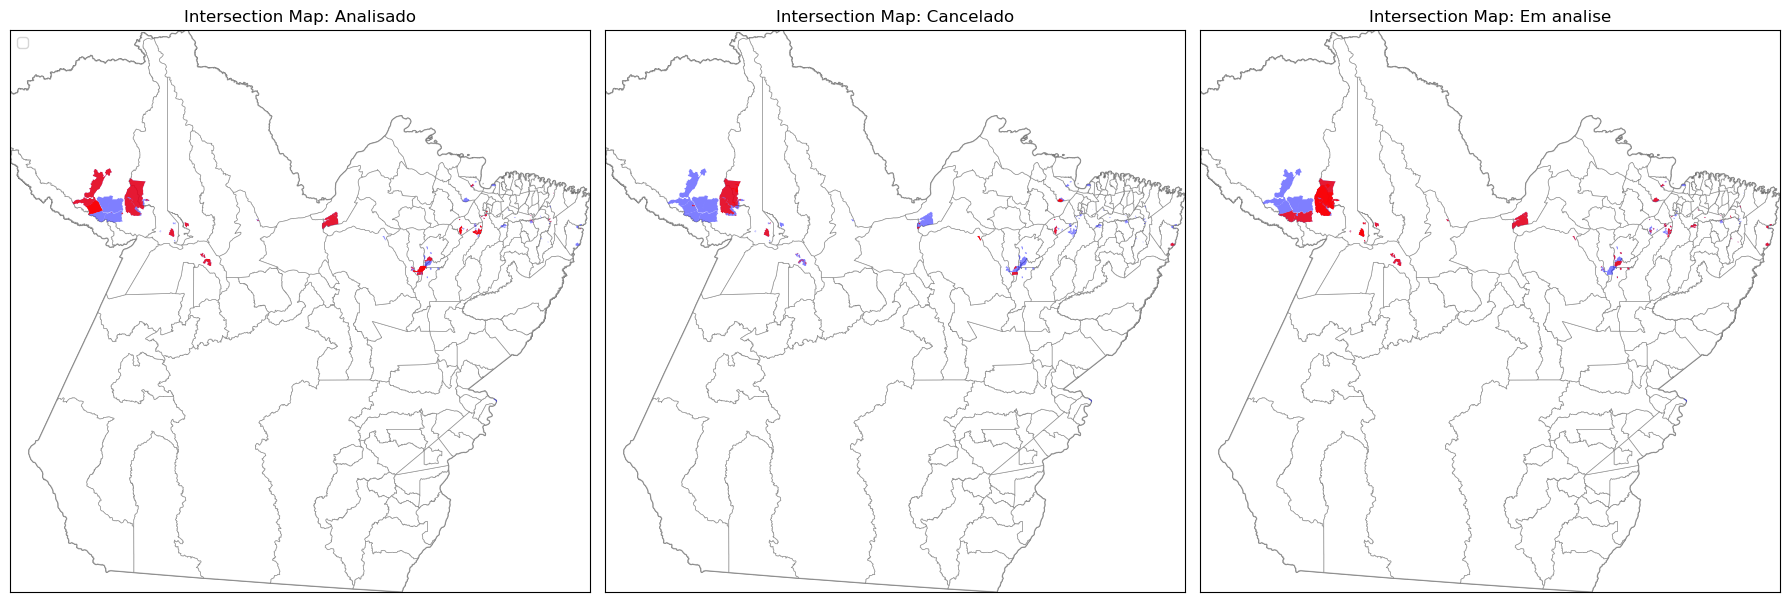

/tmp/ipykernel_1622441/2263440231.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_area = sets[row_idx].geometry.area.sum()
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


Agua_intersect


/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=10)
/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


Agua_intersect
Agua_intersect


/tmp/ipykernel_1622441/2263440231.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  intersection_area += filtered_gdf.geometry.area.sum()


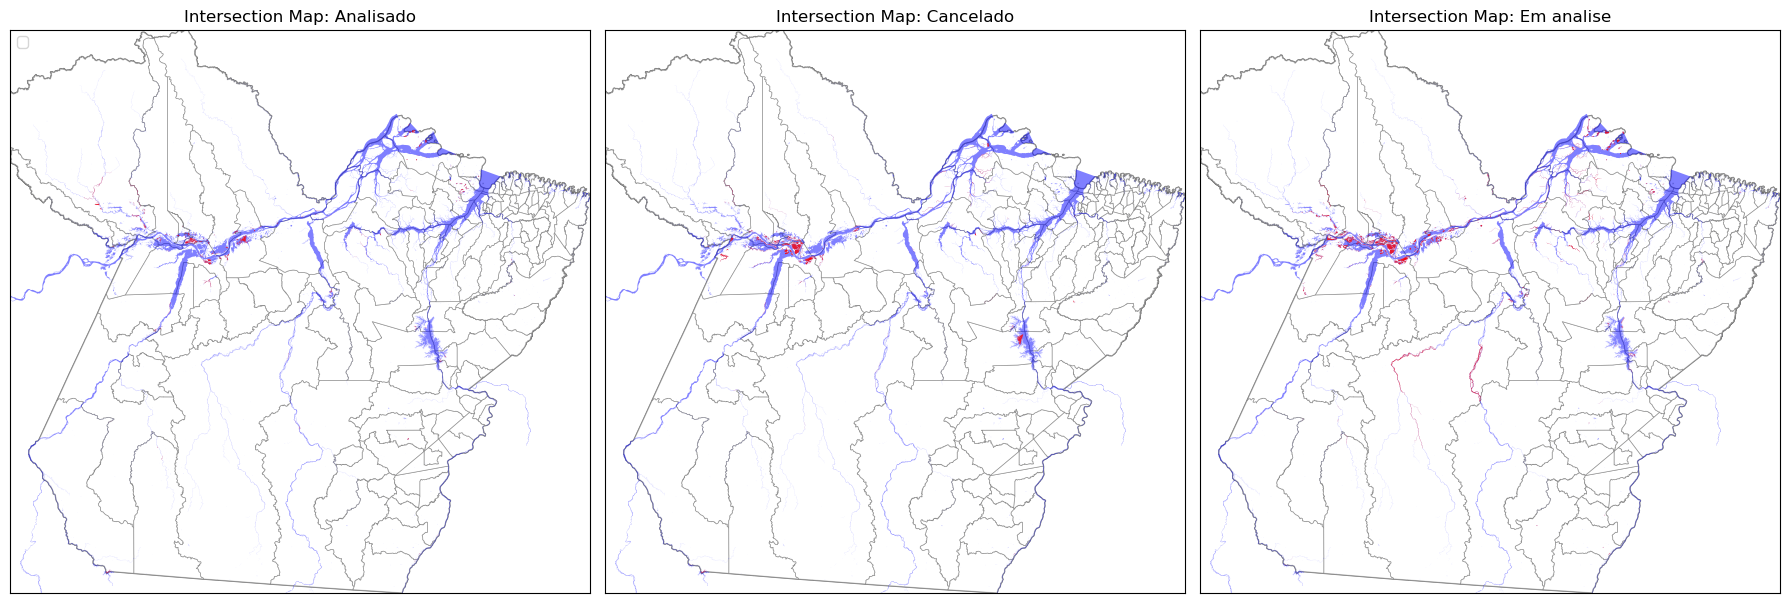

IndexError: list index out of range

In [15]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Standardize and sort the `des_condic` column for CAR geometries
gdf['des_condic'] = gdf['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)


# Subset the intersecting GeoDataFrames to the first few
intersecting_gdfs = intersecting_gdfs[:5]

# Get all unique statuses
unique_statuses = sorted(gdf['des_condic'].unique())

# Iterate over each intersecting GeoDataFrame to create separate figures
for row_idx, intersecting_gdf in enumerate(intersecting_gdfs):
    # Calculate a reasonable figure size based on the number of statuses
    fig_width = max(12, len(unique_statuses) * 6)
    fig_height = 8  # Set a fixed height for consistency

    # Calculate total area of the relevant set
    total_area = sets[row_idx].geometry.area.sum()

    # Initialize intersection area for the category
    intersection_area = 0

    # Create a figure with subplots for each status
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(unique_statuses),
        figsize=(fig_width, fig_height),
    )

    # Ensure axes is iterable even for a single status
    if len(unique_statuses) == 1:
        axes = [axes]

    # Iterate over statuses for columns
    for col_idx, status in enumerate(unique_statuses):
        ax = axes[col_idx]
        print(names[row_idx])
        # Filter the GeoDataFrame by the current status
        filtered_gdf = intersecting_gdf[intersecting_gdf["des_condic"] == status]

        # Accumulate the intersection area
        intersection_area += filtered_gdf.geometry.area.sum()

        if not filtered_gdf.empty:
            # Plot UF boundaries
            uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=0.5, label='UF')

            # Plot city boundaries
            g_m.plot(ax=ax, color='white', edgecolor='grey', linewidth=0.5, alpha=0.7, label='Cities')

            # Plot the relevant set geometry
            sets[row_idx].plot(ax=ax, color='blue', alpha=0.5, label='CAT')

            # Plot the filtered GeoDataFrame
            filtered_gdf.plot(ax=ax, color='red', alpha=0.8, label=f"Status: {status}")

            # Set title for the subplot
            ax.set_title(f"Intersection Map: {status}", fontsize=12)

        else:
            # If no data, set an empty plot with a message
            ax.text(0.5, 0.5, "No Data", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            ax.set_title(f"No Intersection for Status: {status}", fontsize=12)

        # Remove axis ticks for cleaner visualization
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_ylim(uf.total_bounds[1], uf.total_bounds[3])
        ax.set_xlim(uf.total_bounds[0], uf.total_bounds[2])

        # Add legend for the first subplot in each figure
        if col_idx == 0:
            ax.legend(loc="upper left", fontsize=10)


    # Tighten layout to minimize white space
    plt.tight_layout()

    # Save or display the figure
    plt.savefig(f"intersection_map_row_{row_idx + 1}.png", dpi=300)
    plt.show()


In [17]:
import pandas as pd

print(intersecting_gdf['property_ids'])

print(gdf.columns)
# Define the grouping based on 'des_condic' as provided
grouped_conditions = {
    "Analisado": gdf[gdf['des_condic'].str.startswith("Analisado")],
    "Cancelado": gdf[gdf['des_condic'].str.startswith("Cancelado")],
    "Em analise": gdf[~gdf['des_condic'].str.startswith(("Analisado", "Cancelado"))]
}

# Initialize a dictionary to store the stats for each group
group_stats = {}

# Iterate over each group to calculate the stats
for group_name, group_data in grouped_conditions.items():
    total_area = group_data['area'].sum()  # Total area
    total_overlap_area = group_data['intersection_area'].sum()  # Total overlapped area
    num_cars = len(group_data)  # Number of CARs

    # Store the computed stats in the dictionary
    group_stats[group_name] = {
        'Area Total': total_area,
        'Area Sobreposta': total_overlap_area * 0.5,
        'Numero de CARs': num_cars,
    }

# Print the stats for each group
for group_name, stats in group_stats.items():
    print(f"{group_name}:")
    for stat_name, stat_value in stats.items():
        if stat_name == 'Numero de CARs':
            print(f"  {stat_name}: {stat_value}")
        else:
            print(f"  {stat_name}: {100 * 111 * 110.8 * stat_value / 1000000:.1f} mHa")
    print("\n")


KeyError: 'property_ids'

In [ ]:

# Merge intersecting data with original properties (gdf) to include property info
intersecting_with_info = intersecting_gdf.merge(
    gdf, 
    left_on="property_id", 
    right_index=True, 
    suffixes=("_intersection", "_property")
)
# Sort by intersection area in descending order
intersecting_with_info_sorted = intersecting_with_info.sort_values(by="intersection_area", ascending=False)

# Print detailed information about the top 10 overlapping properties
print("Top 10 Overlapping Properties by Intersection Area:")
intersecting_with_info_sorted.head(10)


In [ ]:
for name, gdf in datasets.items():for

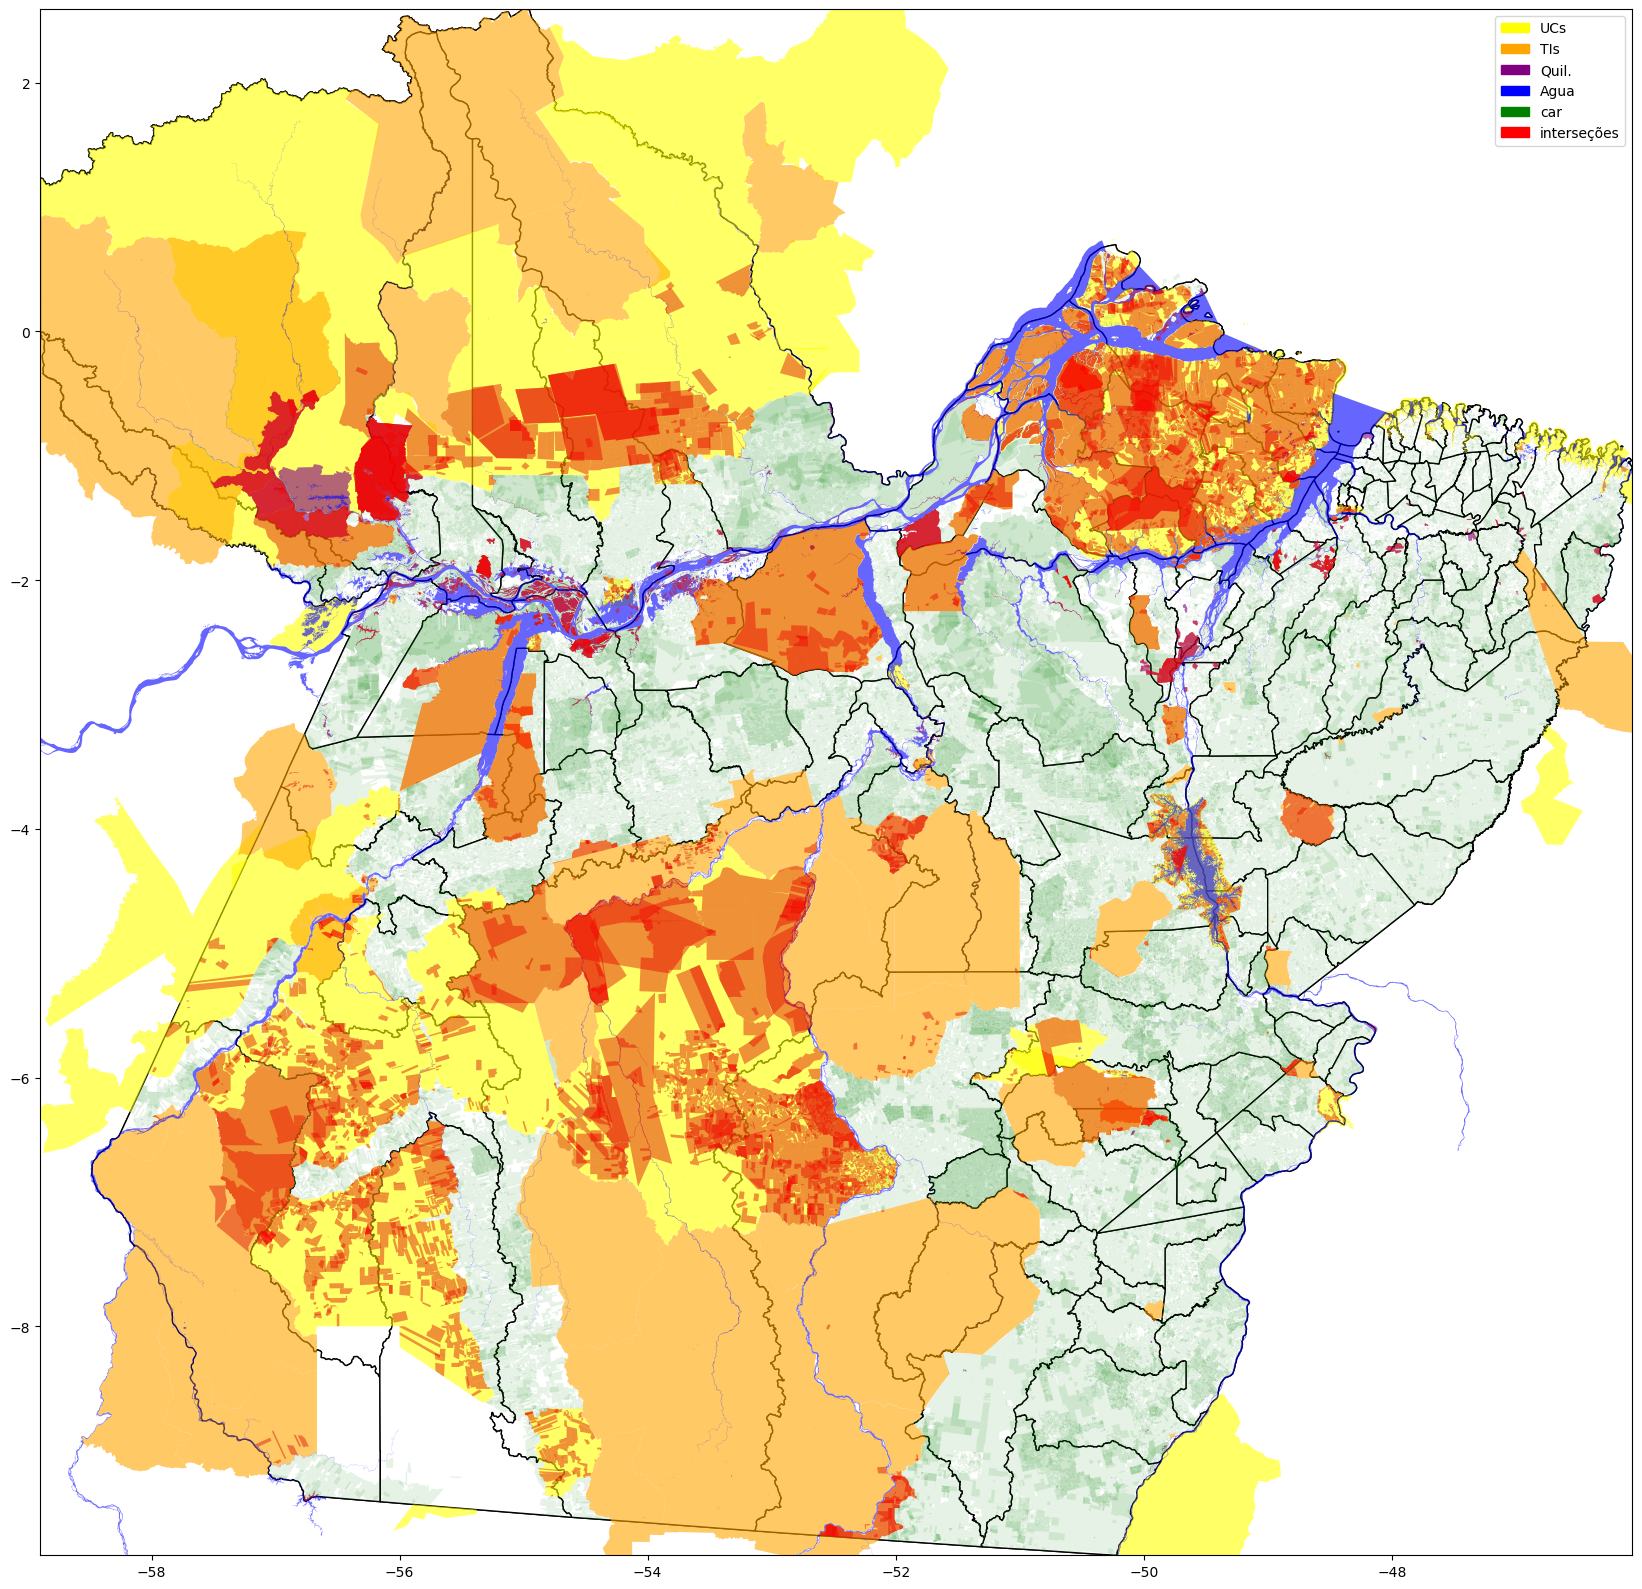

In [75]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Assuming these variables are already defined:
# q_is: List of datasets (like categories of data)
# datasets: Dictionary where each dataset is stored (each corresponding to a key in q_is)
# uf, municipios, car, intersect: GeoDataFrames for plotting
# cores: List of colors corresponding to each dataset
car=gdf
i = 0  # Index for accessing colors

q_is = ["UCs", "TIs", "Quil.", "Agua"]  # List of datasets to plot
cores= ['yellow', 'orange', 'purple', 'blue']  # List of colors for each dataset
fig, ax = plt.subplots(figsize=(30, 16), dpi=100)
    # Plot the base maps: States (uf) and Municipalities (municipios)
uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)

    # Initialize a list for storing legend proxies
proxy_artists = []
    # Plot the dataset (dset) with the corresponding color
for i,dset in enumerate(q_is):
    # Create a new figure and axis
    datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[i], alpha=0.6)    

    

            # Plot intersections (red color)

    
    
    
    proxy = mpatches.Patch(color=cores[i], label=dset)  # Create a legend patch for this dataset
    proxy_artists.append(proxy)
    

    # Plot the CAR data (green color)
car_plot_obj = car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)
car_proxy = mpatches.Patch(color='green', label='car')  # Add a legend for CAR data
proxy_artists.append(car_proxy)
for i,dset in enumerate(q_is):
    intersect=intersecting_gdfs[i]
    i_obj = intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
    i_proxy = mpatches.Patch(color='red', label='interseções')  # Add a legend for intersections

proxy_artists.append(i_proxy)
  # Add the legend to the plot
ax.legend(handles=proxy_artists)
ax.set_ylim(uf.total_bounds[1], uf.total_bounds[3])
ax.set_xlim(uf.total_bounds[0], uf.total_bounds[2])

    # Adjust the layout to avoid overlap
plt.tight_layout()


plt.show()
    # Close the figure to free memory
plt.close()


                                    property_i         uc_id  intersecti  \
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  0000.00.0067    0.000187   
1  PA-1500503-46AB8910852449A98F06624E1E71B5FA  0000.00.0067    0.000224   
2  PA-1500503-4E9733D77054479B9CF019748117C251  0000.00.0067    0.000194   
3  PA-1500503-AB02627E34E04BF8BAC2F93B87BA744A  0000.00.0067    0.012330   
4  PA-1500503-1F7A7E9415D848449F33C83929B742E1  0000.00.0067    0.002349   

   overlap_ar                                           geometry  \
0    0.000187  POLYGON ((-52.90082 -0.52911, -52.90338 -0.517...   
1    0.000224  POLYGON ((-53.15803 -0.76515, -53.15868 -0.766...   
2    0.000194  POLYGON ((-53.1595 -0.76853, -53.16043 -0.7702...   
3    0.012330  POLYGON ((-53.13818 -0.70302, -53.13752 -0.703...   
4    0.002349  POLYGON ((-53.28416 -0.72251, -53.28409 -0.722...   

                                    cod_imovel  des_condic  
0  PA-1500503-19C8BC4DC0E240539194219663BDCFF1  Em analise  
1  PA-150050

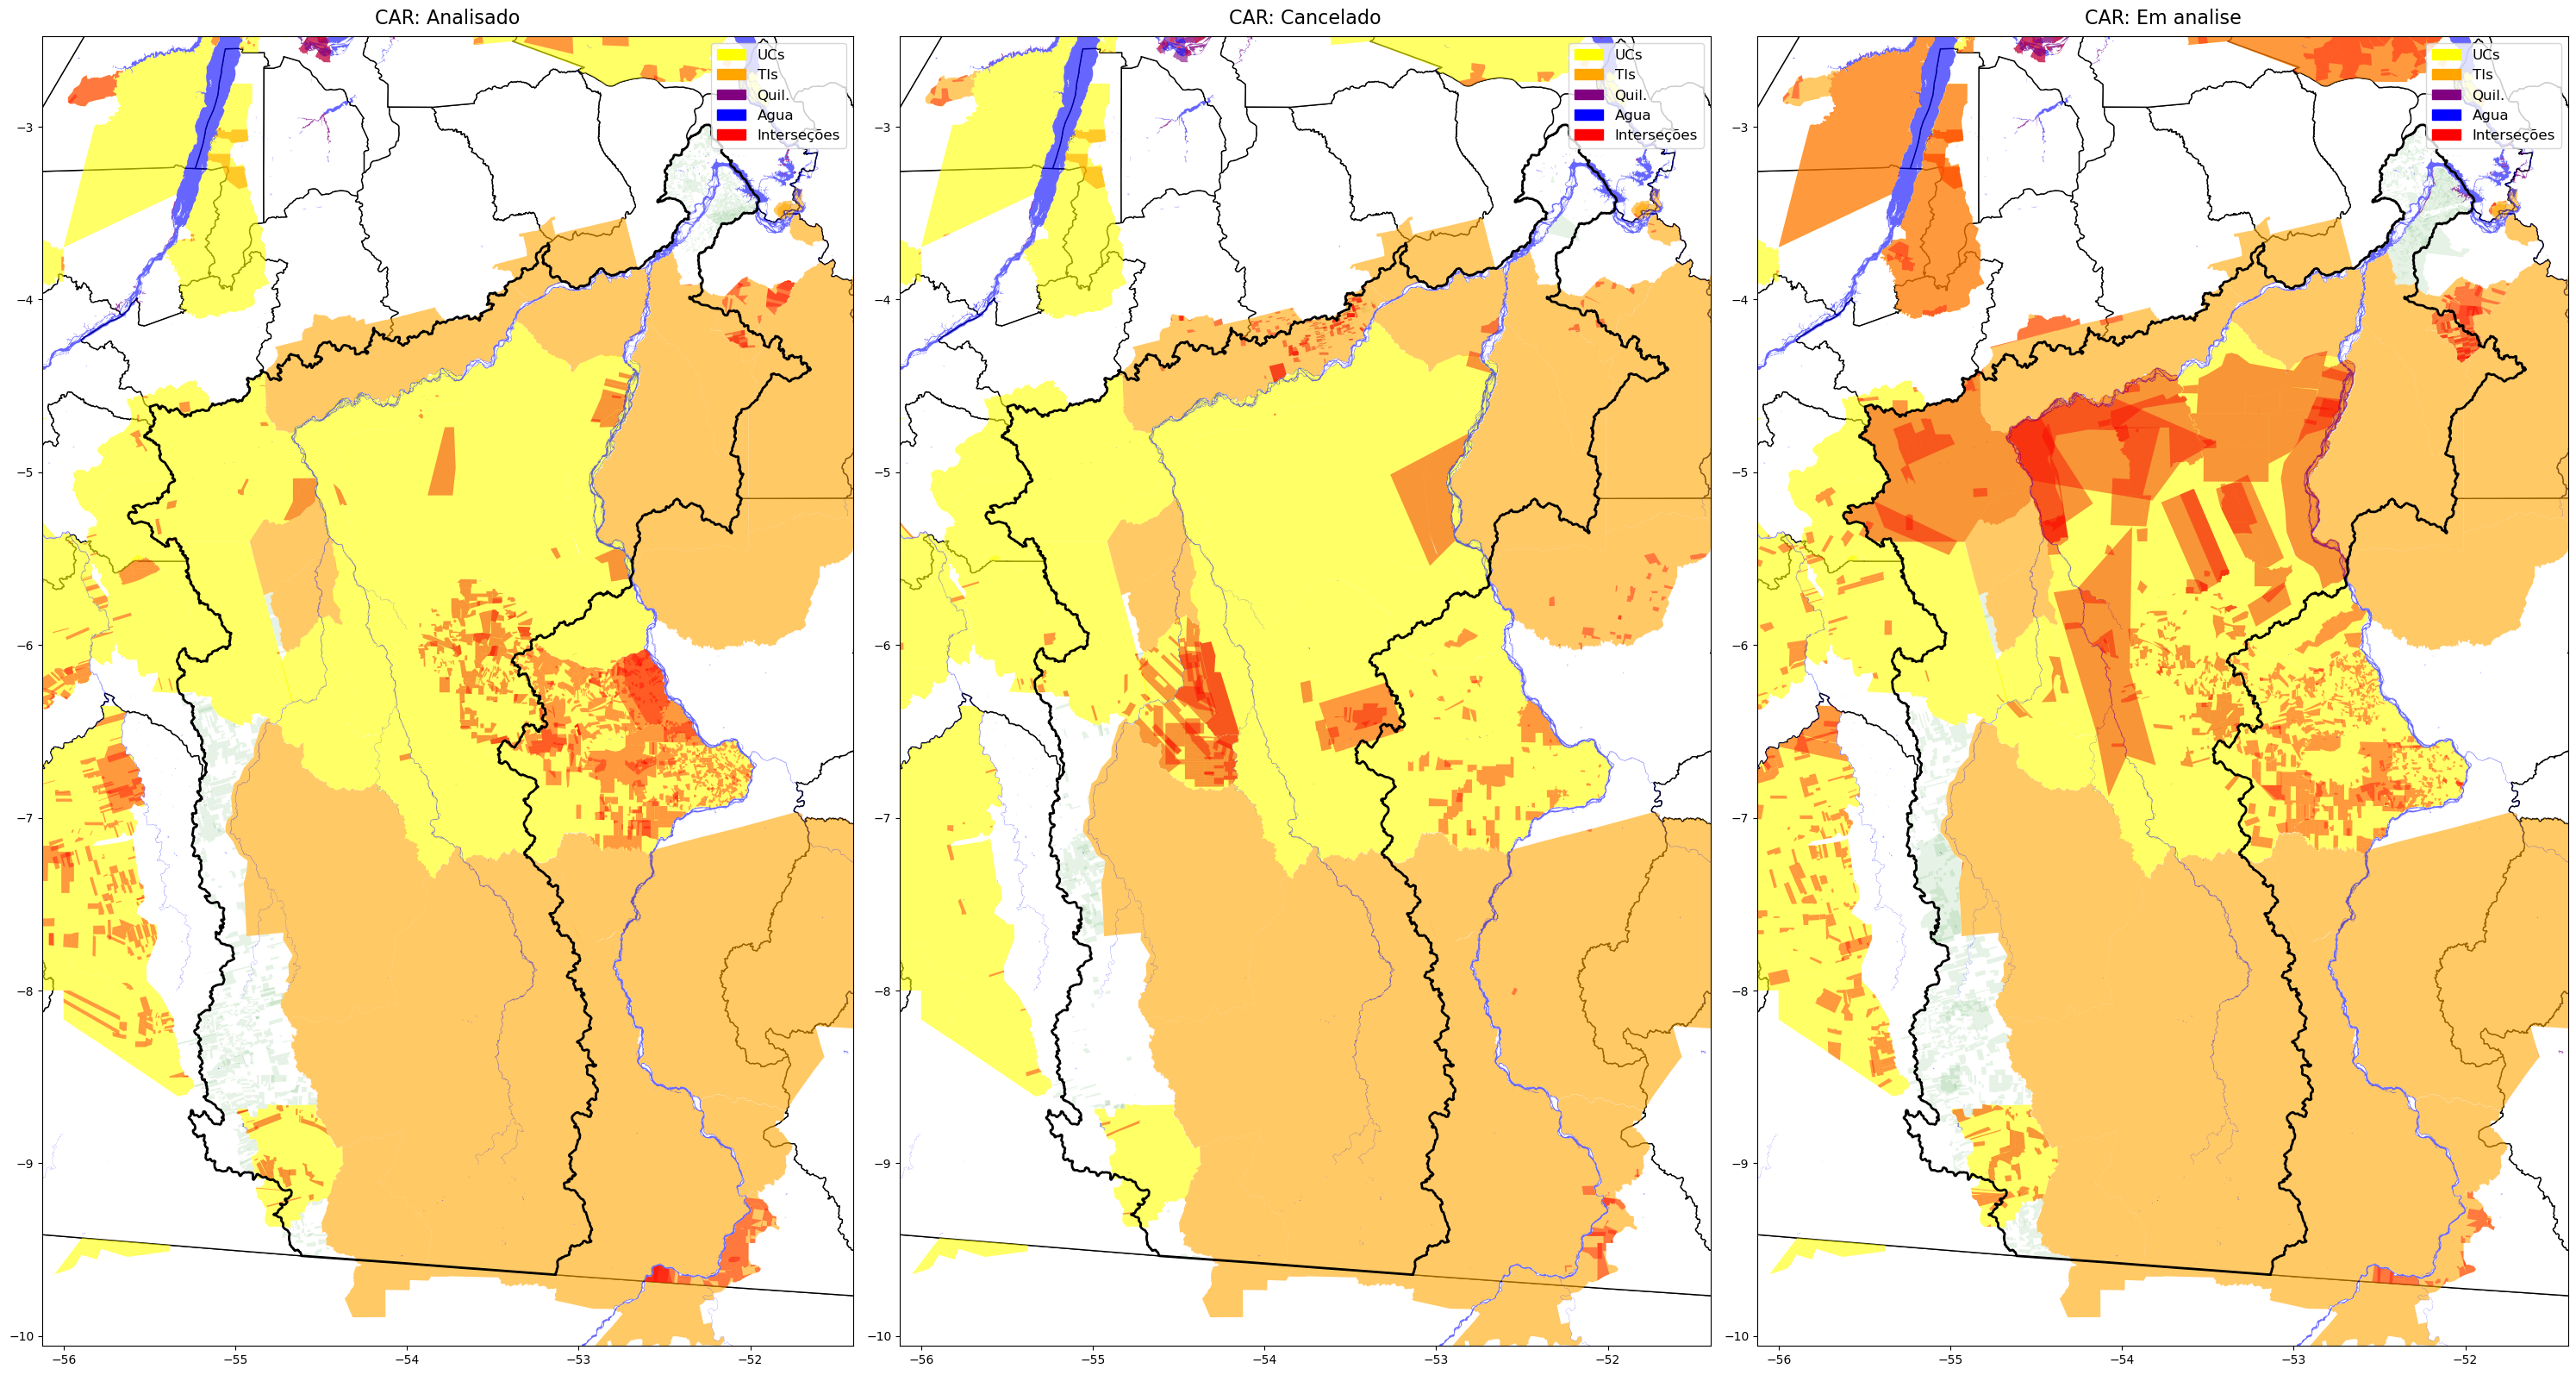

In [68]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

print(intersecting_gdfs[0].head())
# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Assuming these variables are already defined:
# car: The CAR GeoDataFrame (gdf or car)
# uf, municipios: GeoDataFrames for base plotting
# intersecting_gdfs: GeoDataFrame with intersection data
# q_is: List of datasets to plot (UCs, TIs, Quil., Agua)
# datasets: Dictionary where each dataset is stored (corresponding to keys in q_is)
# cores: List of colors corresponding to each dataset

# Filter CAR data for Altamira (adjust if needed based on the correct column name)
altamira_car = car[car['municipio'].str.contains('altamira', case=False, na=False)]

# Coordinates for Altamira (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = altamira_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = altamira_car[altamira_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Altamira with a darker color and thicker line
    altamira = g_m[g_m['NM_MUN'].str.contains('altamira', case=False, na=False)]  # Filter Altamira from municipios
    altamira.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Altamira
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Altamira)
    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Filter CAR data for Tucuruí (adjust if needed based on the correct column name)
tucurui_car = car[car['municipio'].str.contains('tucuruí', case=False, na=False)]

# Coordinates for Tucuruí (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = tucurui_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = tucurui_car[tucurui_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Tucuruí with a darker color and thicker line
    tucurui = g_m[g_m['NM_MUN'].str.contains('tucuruí', case=False, na=False)]  # Filter Tucuruí from municipios
    tucurui.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Tucuruí
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Tucuruí)
    ax.set_xlim(minx - 0.5, maxx + 0.5)
    ax.set_ylim(miny - 0.5, maxy + 0.5)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()


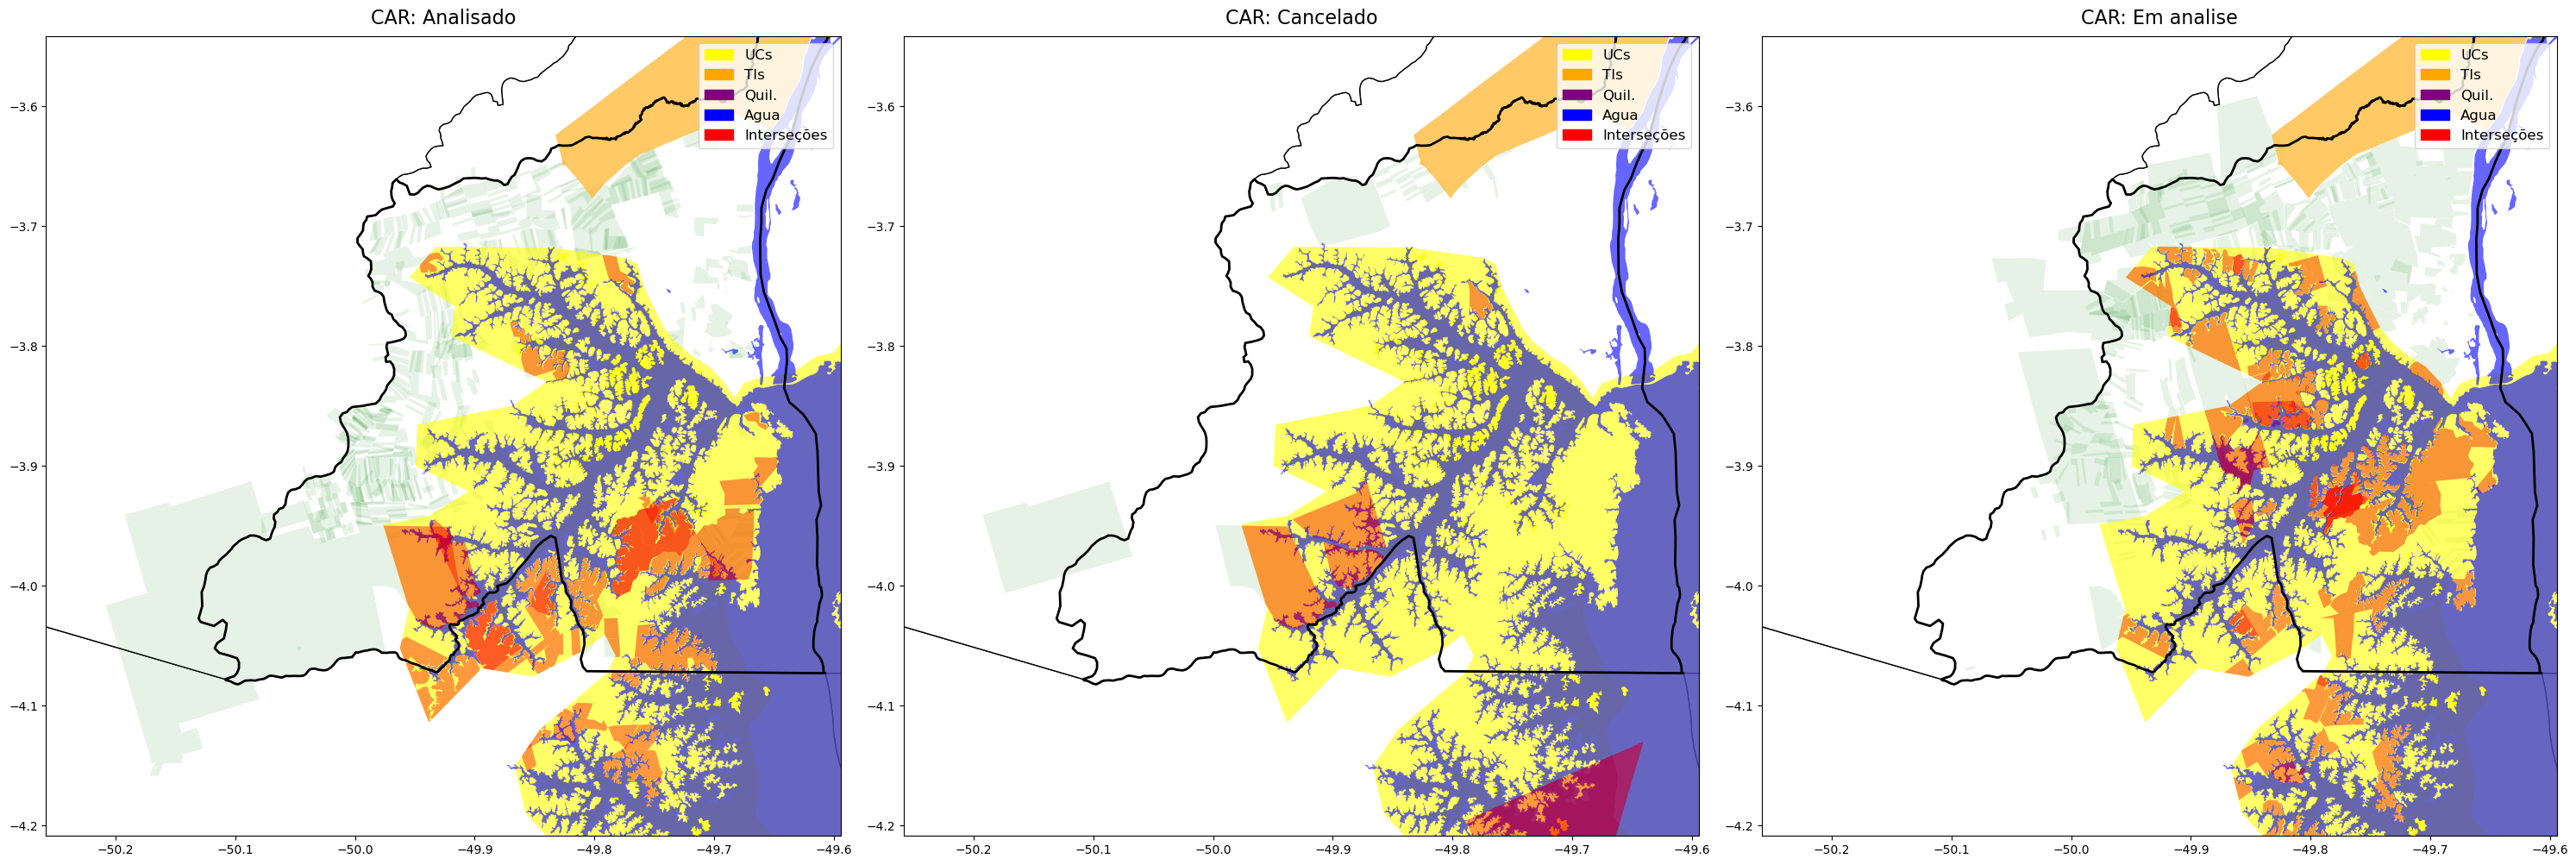

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

car = gdf  # Assuming car is the GeoDataFrame containing the CAR data

# Create a new column for condition description
car["desc_cond"] = car['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Filter CAR data for Tucuruí (adjust if needed based on the correct column name)
tucurui_car = car[car['municipio'].str.contains('tucurui', case=False, na=False)]

# Coordinates for Tucuruí (get bounds of the filtered CAR data)
minx, miny, maxx, maxy = tucurui_car.total_bounds

# Define CAR categories
conditions = ['Analisado', 'Cancelado', 'Em analise']

# Create a subplot grid: 1 row and 3 columns (one for each condition)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 16), dpi=100)

# Initialize a list for storing legend proxies
proxy_artists = []

# Loop through each condition and plot
for i, cond in enumerate(conditions):
    ax = axes[i]  # Access the subplot for the condition
    
    # Plot the base maps: States (uf) and Municipalities (municipios)
    uf.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    g_m.plot(ax=ax, color='white', edgecolor='black', linewidth=1, alpha=1)
    
    # Plot the filtered CAR data for the current condition
    condition_car = tucurui_car[tucurui_car['desc_cond'] == cond]  # Filter for the condition
    condition_car.plot(ax=ax, color='green', edgecolor='black', linewidth=0.00001, alpha=0.1)

    # Plot each dataset (dset) with corresponding colors
    for j, dset in enumerate(q_is):
        datasets[dset].plot(ax=ax, edgecolor='black', linewidth=0, color=cores[j], alpha=0.6)
        proxy = mpatches.Patch(color=cores[j], label=dset)  # Create a legend patch for this dataset
        proxy_artists.append(proxy)
    
        # Filter intersections based on the current condition
        condition_intersect = intersecting_gdfs[j][intersecting_gdfs[j]['des_condic'] == cond]
        condition_intersect.plot(ax=ax, color='red', edgecolor='black', linewidth=0.0001, alpha=0.4)
        i_proxy = mpatches.Patch(color='red', label='Interseções')  # Add a legend for intersections
    proxy_artists.append(i_proxy)

    # Plot the boundaries of Tucuruí with a darker color and thicker line
    tucurui = g_m[g_m['NM_MUN'].str.contains('tucuruí', case=False, na=False)]  # Filter Tucuruí from municipios
    tucurui.plot(ax=ax, edgecolor='black', linewidth=2, facecolor='none')  # Darker line for Tucuruí
    
    # Set title for each subplot (condition)
    ax.set_title(f"CAR: {cond}", fontsize=16, pad=10)
    
    # Set the limits for each subplot (centered around Tucuruí)
    ax.set_xlim(minx - 0.05, maxx + 0.05)
    ax.set_ylim(miny - 0.05, maxy + 0.05)
    
    # Add the legend to the plot for each subplot
    ax.legend(handles=proxy_artists, loc='upper right', fontsize=12)
    proxy_artists = []  
# Adjust the layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()

# Close the figure to free memory
plt.close()
